In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/LINCS_small_molecules.tsv")

lincs_df = pd.read_csv(DATA_PATH, sep="\t")

print(lincs_df.shape)
display(lincs_df.head())
print(lincs_df.columns.tolist())

(34418, 8)


,Unnamed: 0,pert_name,target,moa,canonical_smiles,inchi_key,compound_aliases,sig_count
0,BRD-K60230970,MG-132,PSMB1,Proteasome inhibitor,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,-,8257
1,BRD-K50691590,bortezomib,"PSMB2, PSMB5, PSMB1","Proteasome inhibitor, NFKB pathway inhibitor",CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,-,6776
2,BRD-K81418486,vorinostat,"HDAC8, HDAC2, HDAC3, HDAC6, HDAC1",HDAC inhibitor,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,-,3244
3,BRD-K49865102,PD-0325901,MAP2K1,"MEK inhibitor, Protein kinase inhibitor, MAP k...",OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,-,1796
4,BRD-K21680192,mitoxantrone,TOP2A,Topoisomerase inhibitor,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,-,1740


['Unnamed: 0', 'pert_name', 'target', 'moa', 'canonical_smiles', 'inchi_key', 'compound_aliases', 'sig_count']


In [2]:
# Keep only rows with usable chemical structures
lincs_clean = lincs_df.dropna(subset=["canonical_smiles"]).copy()

# Remove blank strings just in case
lincs_clean = lincs_clean[
    lincs_clean["canonical_smiles"].str.strip() != ""
].copy()

# Deduplicate molecules by canonical SMILES
lincs_unique = lincs_clean.drop_duplicates(
    subset="canonical_smiles"
).reset_index(drop=True)

print(f"Original rows: {len(lincs_df):,}")
print(f"Rows with SMILES: {len(lincs_clean):,}")
print(f"Unique molecules: {len(lincs_unique):,}")

display(
    lincs_unique[
        ["pert_name", "canonical_smiles", "inchi_key", "moa", "sig_count"]
    ].head()
)

Original rows: 34,418
Rows with SMILES: 34,418
Unique molecules: 28,576


,pert_name,canonical_smiles,inchi_key,moa,sig_count
0,MG-132,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,Proteasome inhibitor,8257
1,bortezomib,CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,"Proteasome inhibitor, NFKB pathway inhibitor",6776
2,vorinostat,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,HDAC inhibitor,3244
3,PD-0325901,OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,"MEK inhibitor, Protein kinase inhibitor, MAP k...",1796
4,mitoxantrone,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,Topoisomerase inhibitor,1740


In [3]:
from rdkit import Chem

def is_valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None

lincs_unique["valid_smiles"] = lincs_unique["canonical_smiles"].apply(is_valid_smiles)

print(lincs_unique["valid_smiles"].value_counts())

lincs_valid = lincs_unique[
    lincs_unique["valid_smiles"]
].reset_index(drop=True)

print(f"Valid molecules for fingerprinting: {len(lincs_valid):,}")

[15:16:47] SMILES Parse Error: syntax error while parsing: -
[15:16:47] SMILES Parse Error: check for mistakes around position 1:
[15:16:47] -
[15:16:47] ^
[15:16:47] SMILES Parse Error: Failed parsing SMILES '-' for input: '-'
[15:16:47] SMILES Parse Error: syntax error while parsing: restricted
[15:16:47] SMILES Parse Error: check for mistakes around position 1:
[15:16:47] restricted
[15:16:47] ^
[15:16:47] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'


valid_smiles
True     28574
False        2
Name: count, dtype: int64
Valid molecules for fingerprinting: 28,574


In [4]:
import numpy as np
from rdkit.Chem import AllChem, DataStructs

RADIUS = 2
N_BITS = 2048

def smiles_to_morgan(smiles, radius=RADIUS, n_bits=N_BITS):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits
    )
    
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

morgan_fingerprints = np.vstack(
    lincs_valid["canonical_smiles"].apply(smiles_to_morgan).to_numpy()
)

print("Fingerprint matrix shape:", morgan_fingerprints.shape)
print("Data type:", morgan_fingerprints.dtype)
print("Example fingerprint:", morgan_fingerprints[0, :20])

[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerator
[15:17:19] DEPRECATION WARNING: please use MorganGenerat

Fingerprint matrix shape: (28574, 2048)
Data type: float32
Example fingerprint: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [5]:
from pathlib import Path

Path("../data").mkdir(exist_ok=True)

np.save(
    "../data/lincs_morgan_fingerprints_2048.npy",
    morgan_fingerprints
)

lincs_valid.to_csv(
    "../data/lincs_small_molecules_valid_unique.tsv",
    sep="\t",
    index=False
)

print("Saved fingerprint matrix and cleaned metadata.")

Saved fingerprint matrix and cleaned metadata.


In [6]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# 70% train, 30% temporary holdout
X_train, X_temp = train_test_split(
    morgan_fingerprints,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split remaining 30% equally:
# 15% validation, 15% test overall
X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (20001, 2048)
Validation shape: (4286, 2048)
Test shape: (4287, 2048)


In [7]:
BATCH_SIZE = 128

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 157
Validation batches: 34
Test batches: 34


In [8]:
import torch.nn as nn

INPUT_DIM = 2048
LATENT_DIM = 15

class MorganAutoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MorganAutoencoder().to(DEVICE)

print("Using device:", DEVICE)
print(model)

Using device: cpu
MorganAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2048, bias=True)
    (5): Sigmoid()
  )
)


In [10]:
import torch.optim as optim

LEARNING_RATE = 1e-3
NUM_EPOCHS = 50

criterion = nn.BCELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Epochs:", NUM_EPOCHS)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epochs: 50


In [11]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    running_train_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        reconstructed, _ = model(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)

            reconstructed, _ = model(batch)
            loss = criterion(reconstructed, batch)

            running_val_loss += loss.item() * batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Save best model based on validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/lincs_morgan_autoencoder_best.pt"
        )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.5f} | "
        f"Val Loss: {epoch_val_loss:.5f}"
    )

print(f"\nBest validation loss: {best_val_loss:.5f}")
print(f"Best epoch: {best_epoch}")
print("Saved best model to: ../models/lincs_morgan_autoencoder_best.pt")

Epoch 01/50 | Train Loss: 0.12514 | Val Loss: 0.07993
Epoch 02/50 | Train Loss: 0.06893 | Val Loss: 0.05979
Epoch 03/50 | Train Loss: 0.05462 | Val Loss: 0.05055
Epoch 04/50 | Train Loss: 0.04712 | Val Loss: 0.04407
Epoch 05/50 | Train Loss: 0.04124 | Val Loss: 0.03911
Epoch 06/50 | Train Loss: 0.03680 | Val Loss: 0.03531
Epoch 07/50 | Train Loss: 0.03330 | Val Loss: 0.03243
Epoch 08/50 | Train Loss: 0.03032 | Val Loss: 0.02995
Epoch 09/50 | Train Loss: 0.02782 | Val Loss: 0.02811
Epoch 10/50 | Train Loss: 0.02577 | Val Loss: 0.02647
Epoch 11/50 | Train Loss: 0.02399 | Val Loss: 0.02515
Epoch 12/50 | Train Loss: 0.02237 | Val Loss: 0.02394
Epoch 13/50 | Train Loss: 0.02094 | Val Loss: 0.02280
Epoch 14/50 | Train Loss: 0.01959 | Val Loss: 0.02214
Epoch 15/50 | Train Loss: 0.01839 | Val Loss: 0.02125
Epoch 16/50 | Train Loss: 0.01747 | Val Loss: 0.02081
Epoch 17/50 | Train Loss: 0.01660 | Val Loss: 0.02022
Epoch 18/50 | Train Loss: 0.01580 | Val Loss: 0.02006
Epoch 19/50 | Train Loss: 0.

In [12]:
# Reload the best checkpoint (epoch 26)
best_model = MorganAutoencoder().to(DEVICE)

best_model.load_state_dict(
    torch.load(
        "../models/lincs_morgan_autoencoder_best.pt",
        map_location=DEVICE
    )
)

best_model.eval()

print("Best checkpoint loaded.")

Best checkpoint loaded.


In [13]:
test_loss_total = 0.0

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)
        loss = criterion(reconstructed, batch)

        test_loss_total += loss.item() * batch.size(0)

test_loss = test_loss_total / len(test_loader.dataset)

print(f"Test BCE loss: {test_loss:.5f}")

Test BCE loss: 0.01856


In [14]:
correct_bits = 0
total_bits = 0

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)

        # Convert predicted probabilities into predicted 0/1 bits
        predicted_bits = (reconstructed >= 0.5).float()

        correct_bits += (predicted_bits == batch).sum().item()
        total_bits += batch.numel()

bitwise_accuracy = correct_bits / total_bits

print(f"Test bitwise reconstruction accuracy: {bitwise_accuracy:.4f}")

Test bitwise reconstruction accuracy: 0.9954


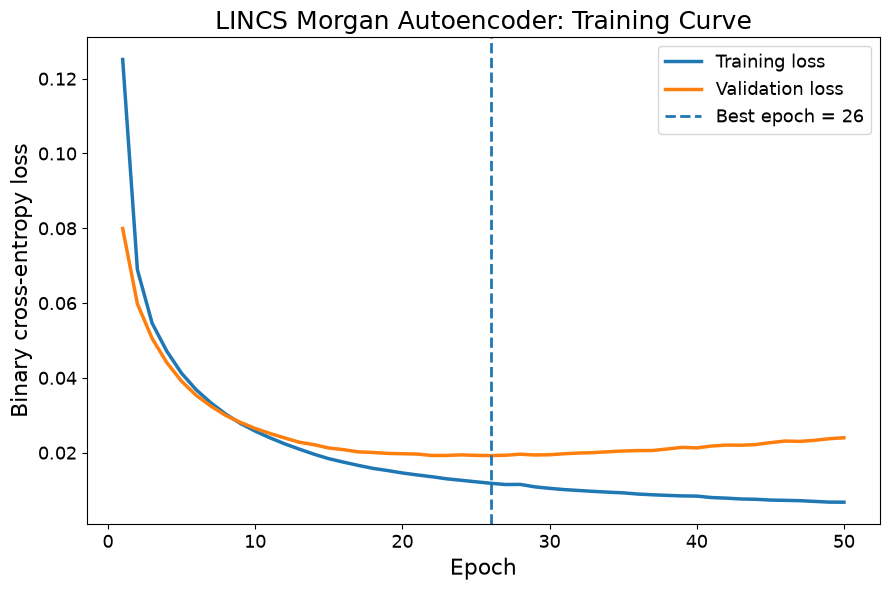

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    linewidth=2.5,
    label="Training loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    linewidth=2.5,
    label="Validation loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=2,
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Binary cross-entropy loss", fontsize=16)
plt.title("LINCS Morgan Autoencoder: Training Curve", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)

plt.tight_layout()

plt.savefig(
    "../figures/lincs_morgan_autoencoder_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

all_true_bits = []
all_pred_probs = []

best_model.eval()

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)

        all_true_bits.append(batch.cpu().numpy())
        all_pred_probs.append(reconstructed.cpu().numpy())

all_true_bits = np.vstack(all_true_bits)
all_pred_probs = np.vstack(all_pred_probs)

# Threshold probabilities into predicted 0/1 fingerprint bits
all_pred_bits = (all_pred_probs >= 0.5).astype(int)

roc_auc_scores = []
f1_scores = []

for true_bits, pred_probs, pred_bits in zip(
    all_true_bits,
    all_pred_probs,
    all_pred_bits
):
    # ROC-AUC is undefined if a molecule has only one class,
    # though that should be rare for Morgan fingerprints.
    if len(np.unique(true_bits)) == 2:
        roc_auc_scores.append(
            roc_auc_score(true_bits, pred_probs)
        )

    f1_scores.append(
        f1_score(true_bits, pred_bits, zero_division=0)
    )

mean_roc_auc = np.mean(roc_auc_scores)
mean_f1 = np.mean(f1_scores)

print(f"Mean per-molecule ROC-AUC: {mean_roc_auc:.4f}")
print(f"Mean per-molecule F1 score: {mean_f1:.4f}")
print(f"Molecules included in ROC-AUC: {len(roc_auc_scores):,}")

Mean per-molecule ROC-AUC: 0.9784
Mean per-molecule F1 score: 0.8762
Molecules included in ROC-AUC: 4,287


In [18]:
LATENT_DIMS = [5, 10, 15, 30, 50]

In [19]:
import copy
import pandas as pd

LATENT_DIMS = [5, 10, 15, 30, 50]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3

bottleneck_results = []
bottleneck_models = {}

for latent_dim in LATENT_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Fresh autoencoder for this bottleneck size
    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ---- Training ----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        candidate_train_losses.append(epoch_train_loss)

        # ---- Validation ----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        candidate_val_losses.append(epoch_val_loss)

        # ---- Early stopping / save best version ----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore the best version of this candidate model
    candidate_model.load_state_dict(best_candidate_state)

    # Save model and results
    bottleneck_models[latent_dim] = candidate_model

    torch.save(
        candidate_model.state_dict(),
        f"../models/lincs_morgan_autoencoder_latent{latent_dim}_best.pt"
    )

    bottleneck_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.5f} "
        f"at epoch {best_candidate_epoch}"
    )

bottleneck_results_df = pd.DataFrame(bottleneck_results)

display(
    bottleneck_results_df.sort_values("best_val_bce")
)


Training bottleneck size: 5
Latent dim 5: best validation BCE = 0.02659 at epoch 46

Training bottleneck size: 10
Early stopping at epoch 33 (best epoch: 25)
Latent dim 10: best validation BCE = 0.02113 at epoch 25

Training bottleneck size: 15
Early stopping at epoch 32 (best epoch: 24)
Latent dim 15: best validation BCE = 0.01900 at epoch 24

Training bottleneck size: 30
Early stopping at epoch 33 (best epoch: 25)
Latent dim 30: best validation BCE = 0.01870 at epoch 25

Training bottleneck size: 50
Early stopping at epoch 34 (best epoch: 26)
Latent dim 50: best validation BCE = 0.01821 at epoch 26


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
4,50,26,0.018212,0.008105,34
3,30,25,0.018696,0.008389,33
2,15,24,0.018996,0.009095,32
1,10,25,0.021130,0.011707,33
0,5,46,0.026593,0.017742,50


In [20]:
import copy
import pandas as pd
import torch
import torch.optim as optim

# Only the bottlenecks missing from yesterday's full range
MISSING_LATENT_DIMS = [2, 25, 100]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3

new_bottleneck_results = []

for latent_dim in MISSING_LATENT_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Fresh model for this bottleneck size
    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ----- Training -----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )
        candidate_train_losses.append(epoch_train_loss)

        # ----- Validation -----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = (
            running_val_loss / len(val_loader.dataset)
        )
        candidate_val_losses.append(epoch_val_loss)

        # ----- Save best checkpoint / early stopping -----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore the best validation-loss version
    candidate_model.load_state_dict(best_candidate_state)

    # Save its weights
    model_path = (
        f"../models/"
        f"lincs_morgan_autoencoder_latent{latent_dim}_best.pt"
    )
    torch.save(candidate_model.state_dict(), model_path)

    # Store its results
    new_bottleneck_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.6f} "
        f"at epoch {best_candidate_epoch}"
    )

# Turn the three new results into a table
new_bottleneck_results_df = pd.DataFrame(new_bottleneck_results)

# Combine with the results table you already made
bottleneck_results_df = pd.concat(
    [bottleneck_results_df, new_bottleneck_results_df],
    ignore_index=True
)

# Safety check: keep one row per bottleneck size
bottleneck_results_df = (
    bottleneck_results_df
    .drop_duplicates(subset="latent_dim", keep="last")
    .sort_values("latent_dim")
    .reset_index(drop=True)
)

display(bottleneck_results_df)


Training bottleneck size: 2
Latent dim 2: best validation BCE = 0.039009 at epoch 48

Training bottleneck size: 25
Early stopping at epoch 34 (best epoch: 26)
Latent dim 25: best validation BCE = 0.018370 at epoch 26

Training bottleneck size: 100
Early stopping at epoch 30 (best epoch: 22)
Latent dim 100: best validation BCE = 0.018182 at epoch 22


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
0,2,48,0.039009,0.036539,50
1,5,46,0.026593,0.017742,50
2,10,25,0.021130,0.011707,33
3,15,24,0.018996,0.009095,32
4,25,26,0.018370,0.008240,34
5,30,25,0.018696,0.008389,33
6,50,26,0.018212,0.008105,34
7,100,22,0.018182,0.009061,30


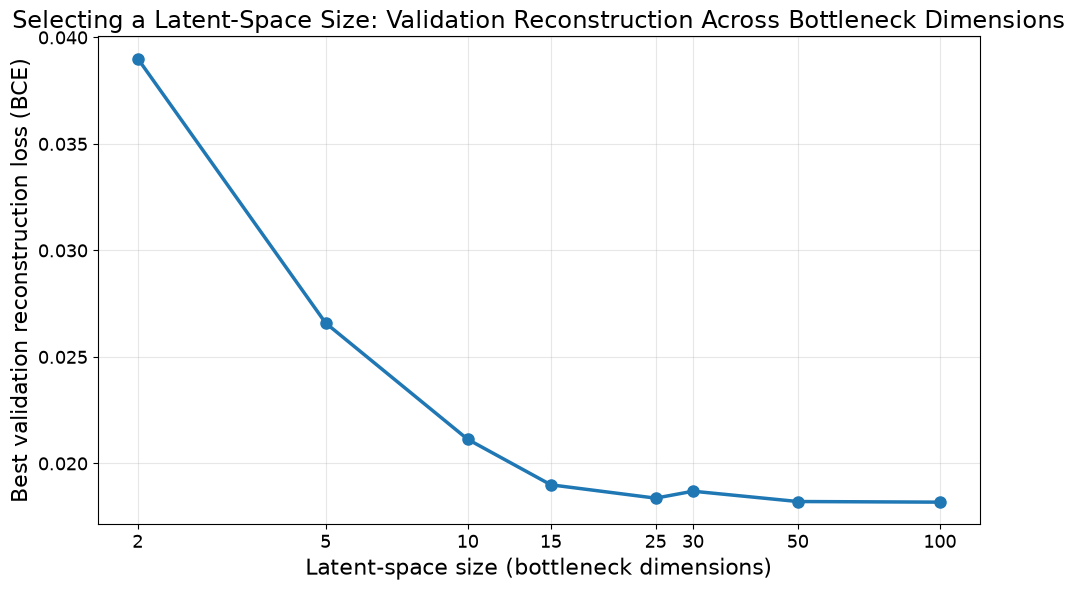

In [22]:
import matplotlib.pyplot as plt

plot_df = bottleneck_results_df.sort_values("latent_dim").copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["latent_dim"],
    plot_df["best_val_bce"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

plt.xscale("log", base=2)

plt.xticks(
    plot_df["latent_dim"],
    labels=plot_df["latent_dim"],
    fontsize=13
)
plt.yticks(fontsize=13)

plt.xlabel(
    "Latent-space size (bottleneck dimensions)",
    fontsize=16
)
plt.ylabel(
    "Best validation reconstruction loss (BCE)",
    fontsize=16
)
plt.title(
    "Selecting a Latent-Space Size: Validation Reconstruction Across Bottleneck Dimensions",
    fontsize=17
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/lincs_bottleneck_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

# Systematic bottleneck sweep: powers of 2
POWER_OF_TWO_DIMS = [2, 4, 8, 16, 32, 64, 128]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

power2_results = []

for latent_dim in POWER_OF_TWO_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Make initialization/comparison reproducible
    set_seed(SEED)

    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ----- Training -----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )
        candidate_train_losses.append(epoch_train_loss)

        # ----- Validation -----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = (
            running_val_loss / len(val_loader.dataset)
        )
        candidate_val_losses.append(epoch_val_loss)

        # ----- Save best version / early stopping -----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore and save best checkpoint for this size
    candidate_model.load_state_dict(best_candidate_state)

    torch.save(
        candidate_model.state_dict(),
        f"../models/lincs_morgan_autoencoder_power2_latent{latent_dim}_best.pt"
    )

    power2_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.6f} "
        f"at epoch {best_candidate_epoch}"
    )

power2_results_df = (
    pd.DataFrame(power2_results)
    .sort_values("latent_dim")
    .reset_index(drop=True)
)

display(power2_results_df)


Training bottleneck size: 2
Latent dim 2: best validation BCE = 0.039226 at epoch 50

Training bottleneck size: 4
Latent dim 4: best validation BCE = 0.029921 at epoch 48

Training bottleneck size: 8
Early stopping at epoch 38 (best epoch: 30)
Latent dim 8: best validation BCE = 0.022643 at epoch 30

Training bottleneck size: 16
Early stopping at epoch 32 (best epoch: 24)
Latent dim 16: best validation BCE = 0.019237 at epoch 24

Training bottleneck size: 32
Early stopping at epoch 34 (best epoch: 26)
Latent dim 32: best validation BCE = 0.018857 at epoch 26

Training bottleneck size: 64
Early stopping at epoch 33 (best epoch: 25)
Latent dim 64: best validation BCE = 0.018295 at epoch 25

Training bottleneck size: 128
Early stopping at epoch 31 (best epoch: 23)
Latent dim 128: best validation BCE = 0.018140 at epoch 23


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
0,2,50,0.039226,0.036484,50
1,4,48,0.029921,0.022887,50
2,8,30,0.022643,0.012952,38
3,16,24,0.019237,0.009528,32
4,32,26,0.018857,0.008944,34
5,64,25,0.018295,0.009053,33
6,128,23,0.018140,0.008723,31


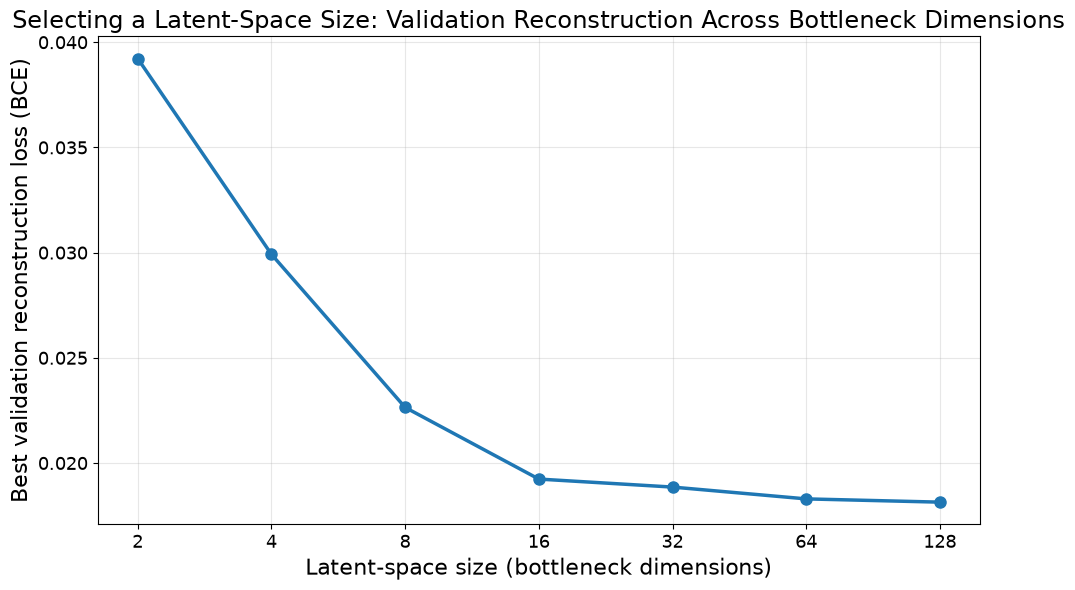

In [24]:
import matplotlib.pyplot as plt

plot_df = power2_results_df.sort_values("latent_dim").copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["latent_dim"],
    plot_df["best_val_bce"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

# These are powers of 2, so use a base-2 log x-axis
plt.xscale("log", base=2)

plt.xticks(
    plot_df["latent_dim"],
    labels=plot_df["latent_dim"],
    fontsize=13
)
plt.yticks(fontsize=13)

plt.xlabel(
    "Latent-space size (bottleneck dimensions)",
    fontsize=16
)
plt.ylabel(
    "Best validation reconstruction loss (BCE)",
    fontsize=16
)
plt.title(
    "Selecting a Latent-Space Size: Validation Reconstruction Across Bottleneck Dimensions",
    fontsize=17
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/lincs_power2_bottleneck_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()